# Define constants

In [1]:
FEATURES_DIR = "../../features"
MODELS_DIR = "../../models"
RANDOM_STATE = 42

import os
from pathlib import Path
import math
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

2026-04-11 23:52:27.470133: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-11 23:52:27.470189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-11 23:52:27.472292: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-11 23:52:27.483084: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 23:52:28.629477: W tensorflow/compiler/tf2

# Load models and features

In [2]:
feature_files = sorted(Path(FEATURES_DIR).glob("*-noisy.npz"))
model_files = sorted(Path(MODELS_DIR).glob("*.h5"))

if not feature_files:
    raise FileNotFoundError(f"No feature files found in {FEATURES_DIR}")

if not model_files:
    raise FileNotFoundError(f"No model files found in {MODELS_DIR}")

feature_cache = {}
for feature_path in feature_files:
    with np.load(feature_path, allow_pickle=True) as data:
        feature_cache[feature_path.stem] = {
            "features": data["features"],
            "labels": data["labels"],
        }

print(f"Loaded {len(model_files)} models and {len(feature_files)} feature sets.")
print("Models:", [path.stem for path in model_files])
print("Feature sets:", [path.stem for path in feature_files])

Loaded 5 models and 4 feature sets.
Models: ['opus-50e', 'opus-50e_2', 'opus_pcm-50e', 'pcm_s16le-50e', 'pcm_s32le-50e']
Feature sets: ['opus-noisy', 'opus_pcm-noisy', 'pcm_s16le-noisy', 'pcm_s32le-noisy']


# Evaluation


[1/5] Evaluating model: opus-50e


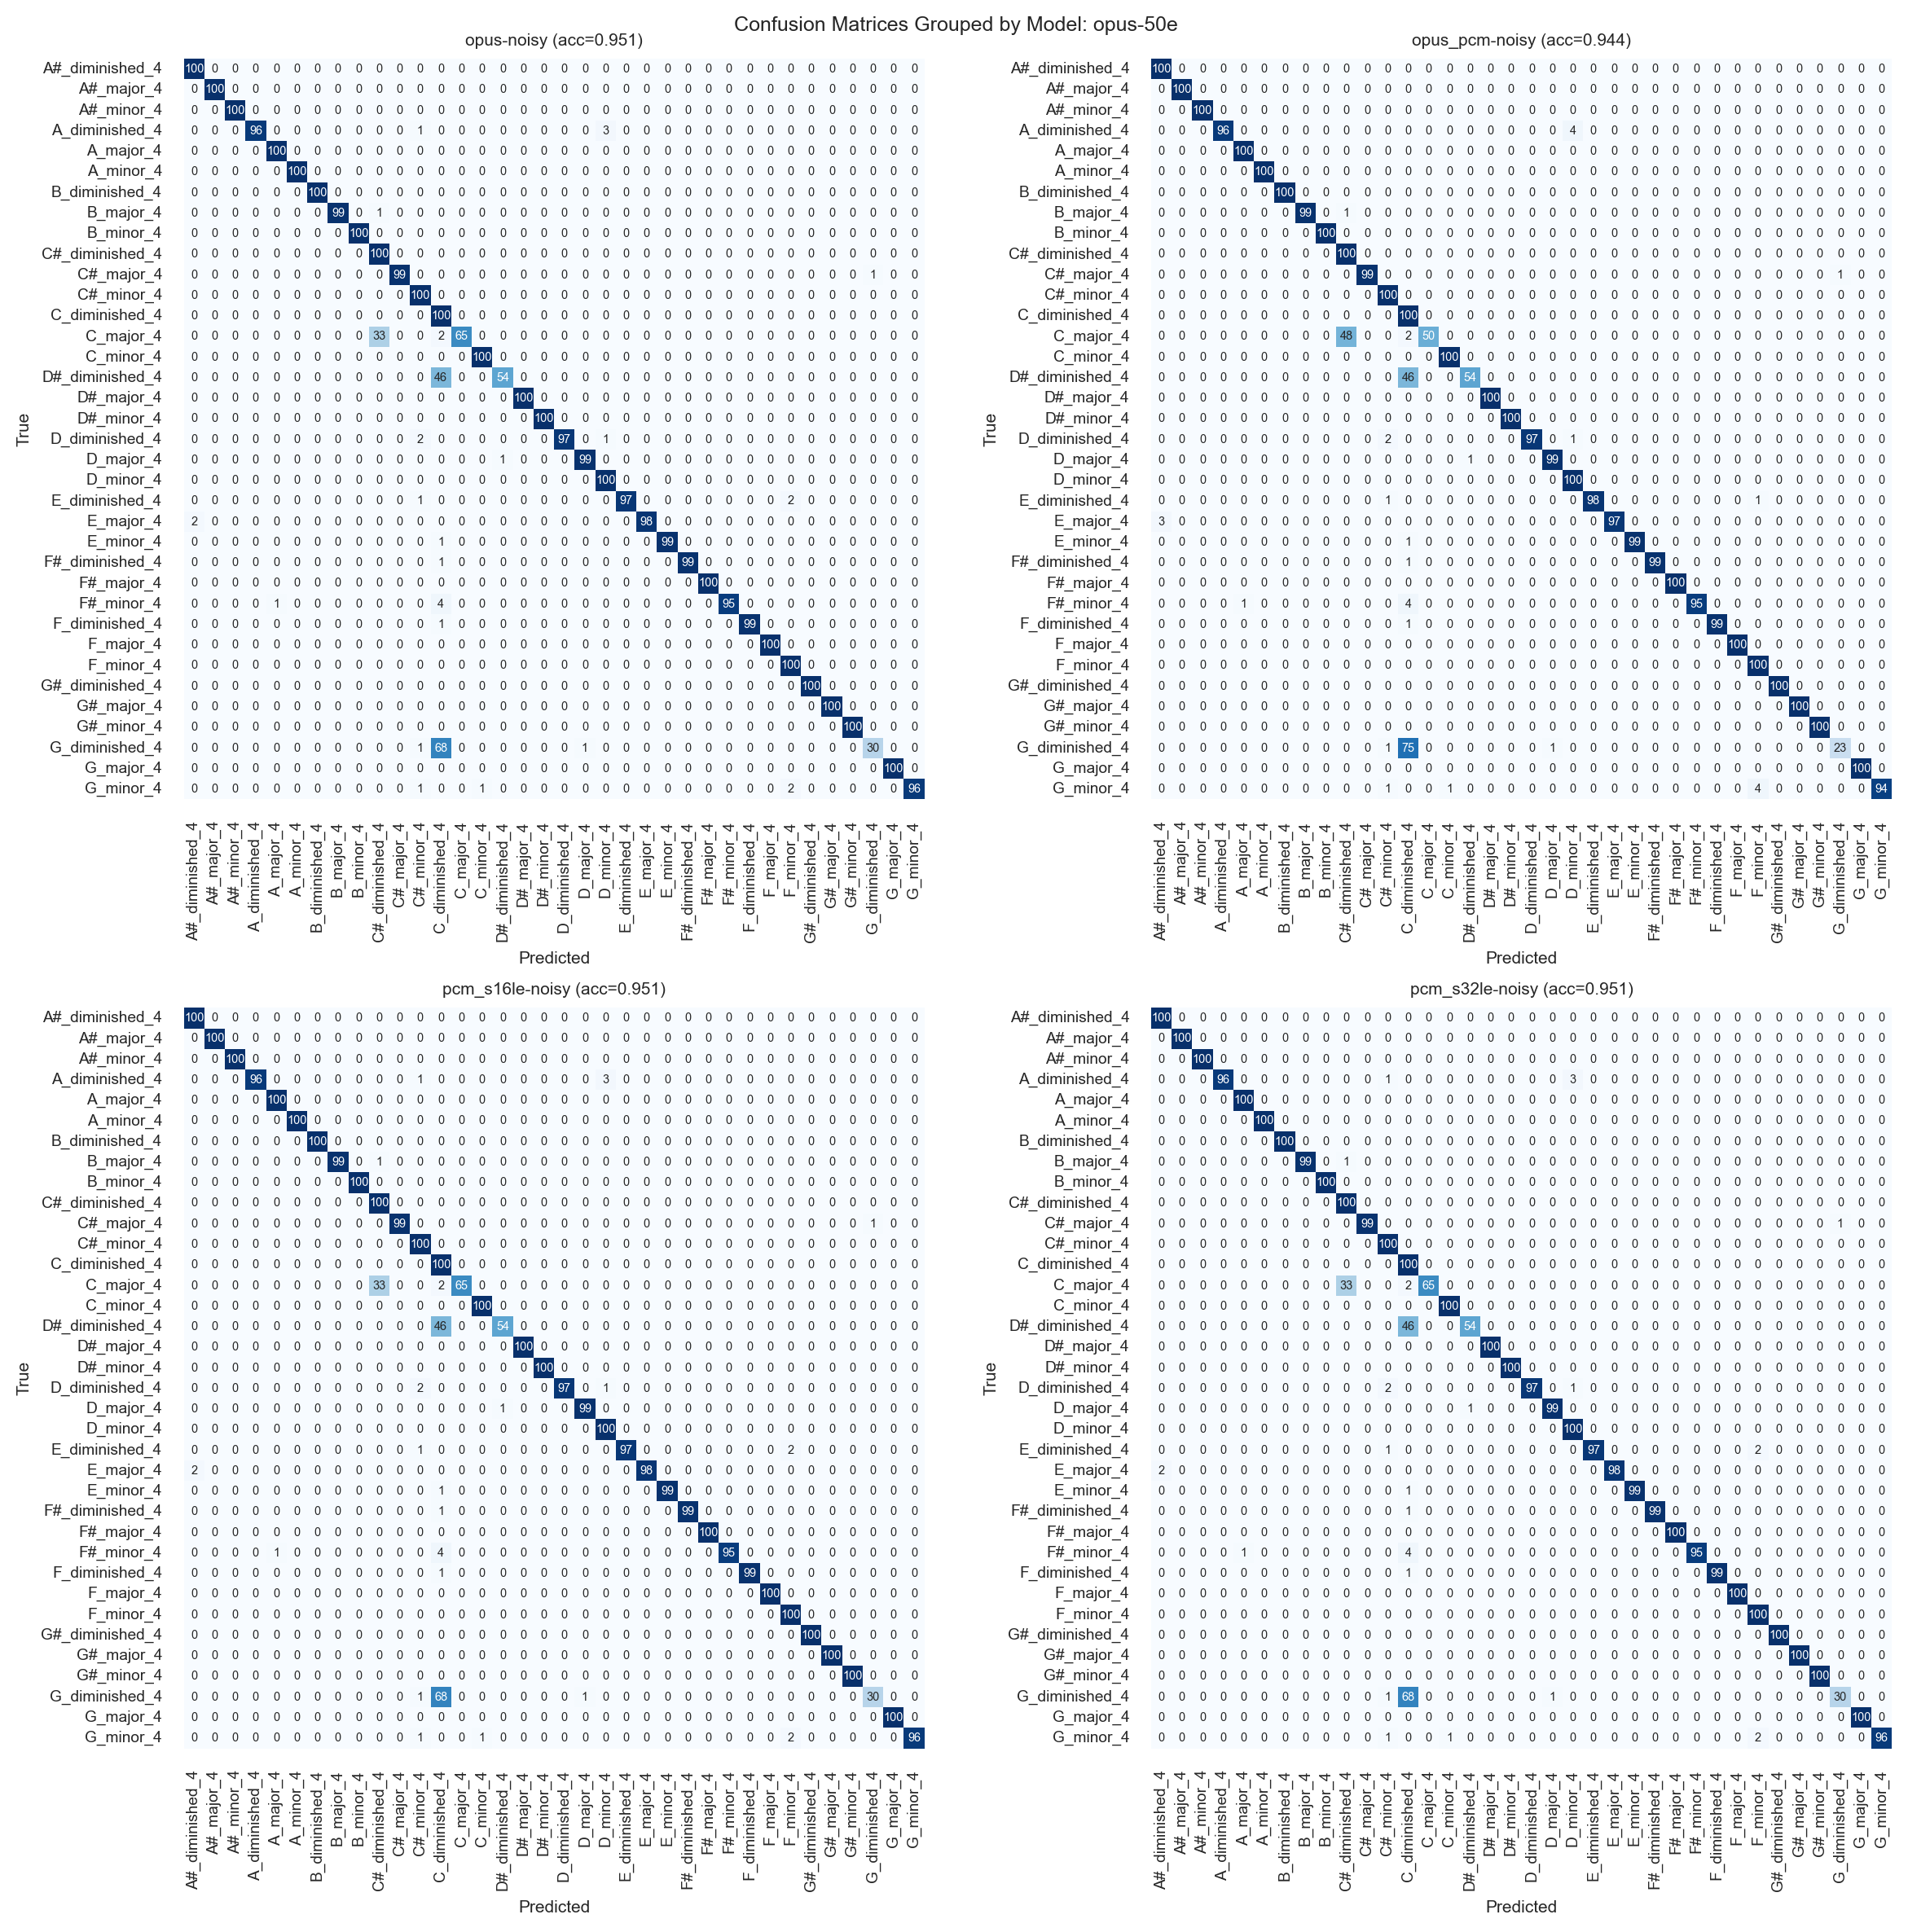

Finished model: opus-50e

[2/5] Evaluating model: opus-50e_2


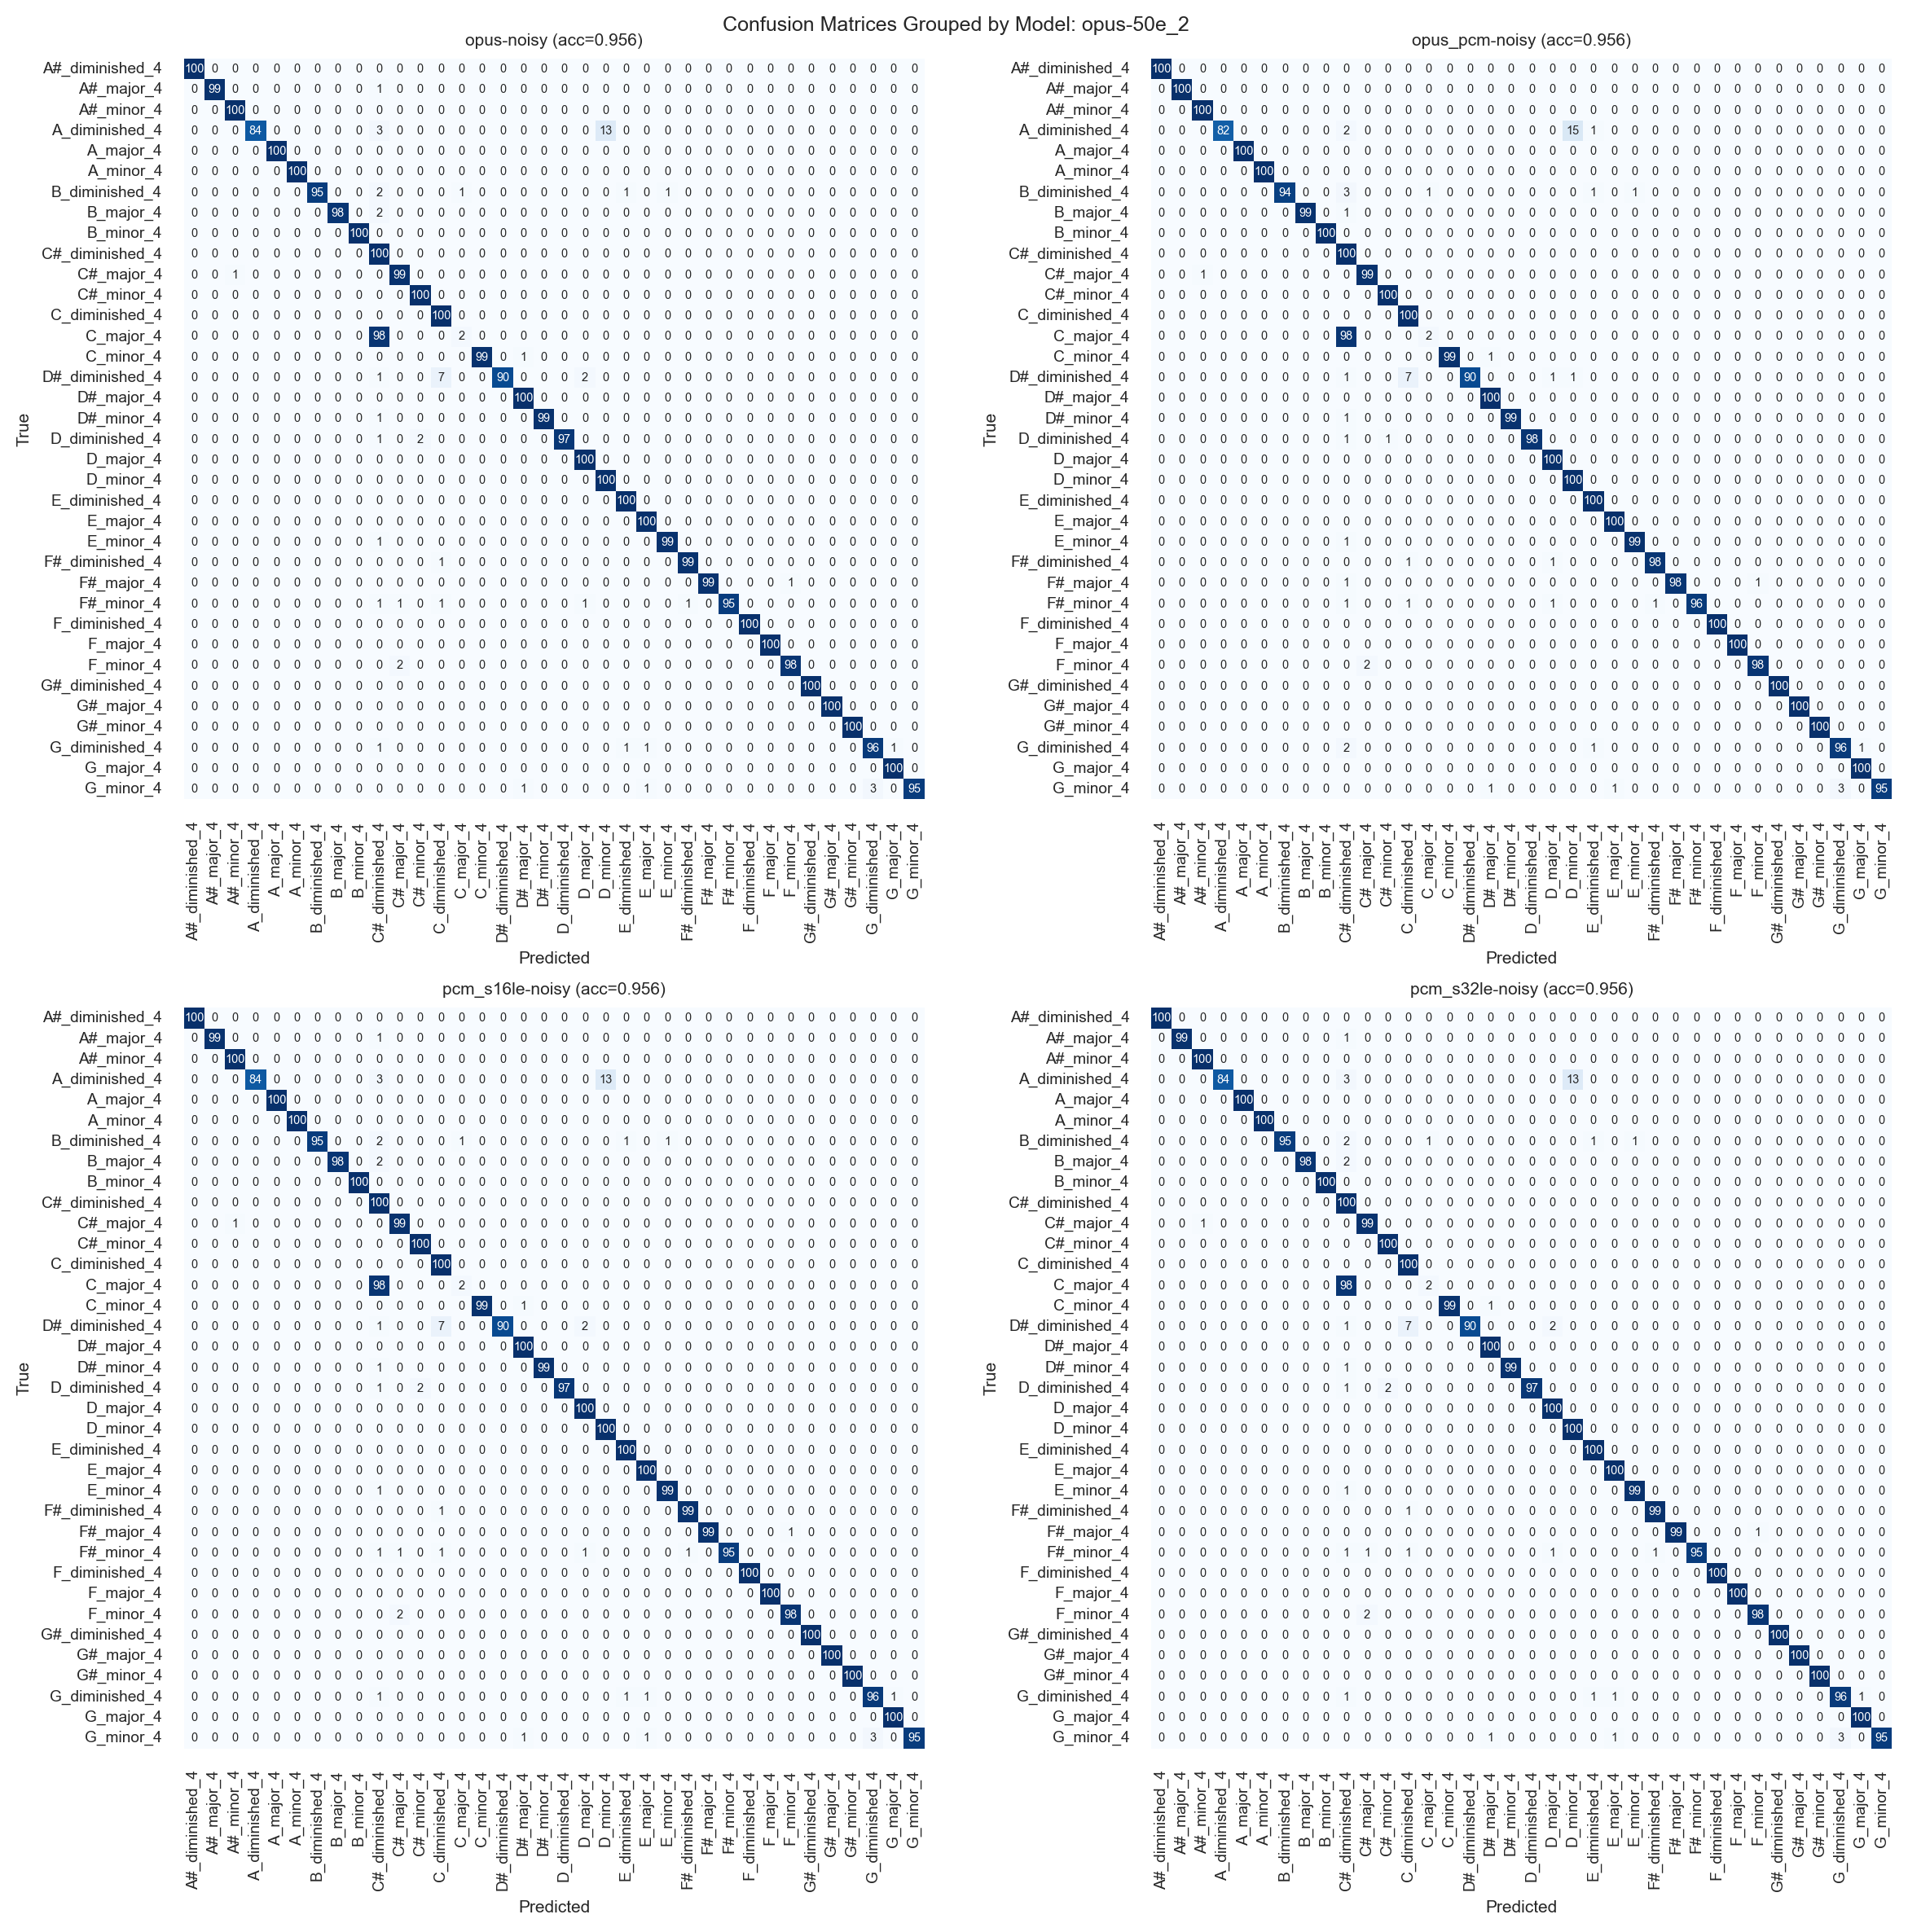

Finished model: opus-50e_2

[3/5] Evaluating model: opus_pcm-50e


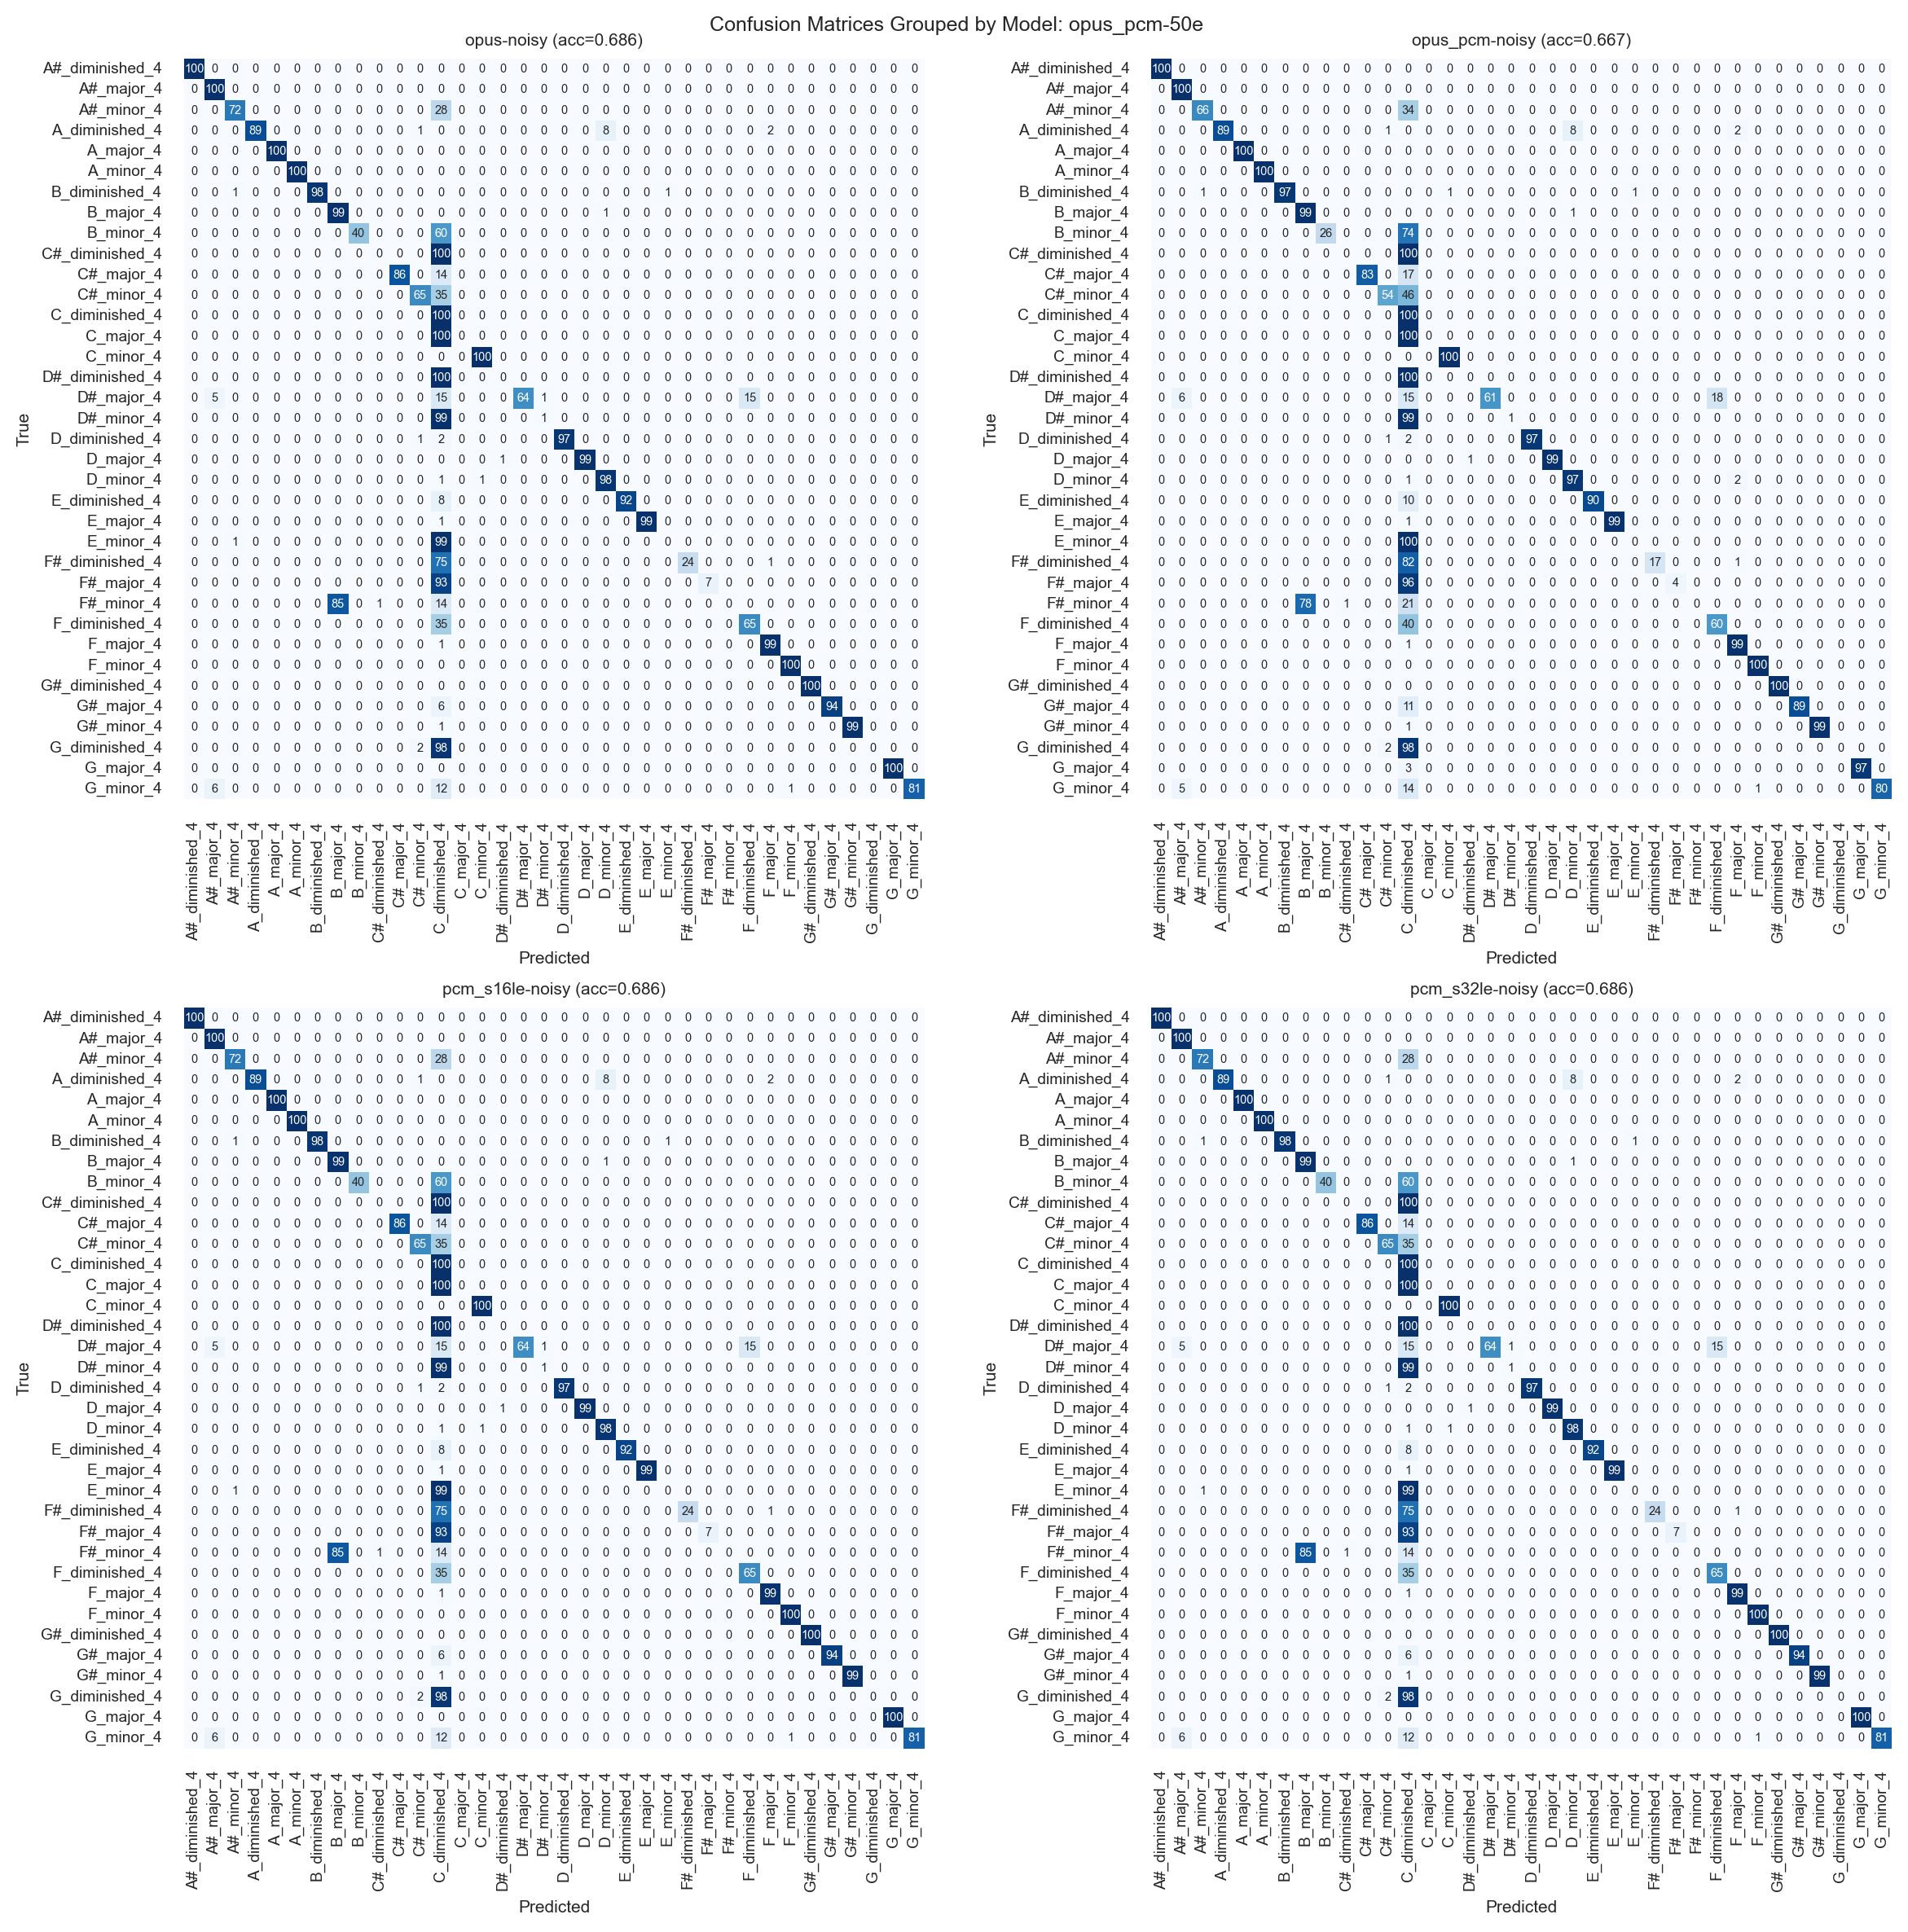

Finished model: opus_pcm-50e

[4/5] Evaluating model: pcm_s16le-50e


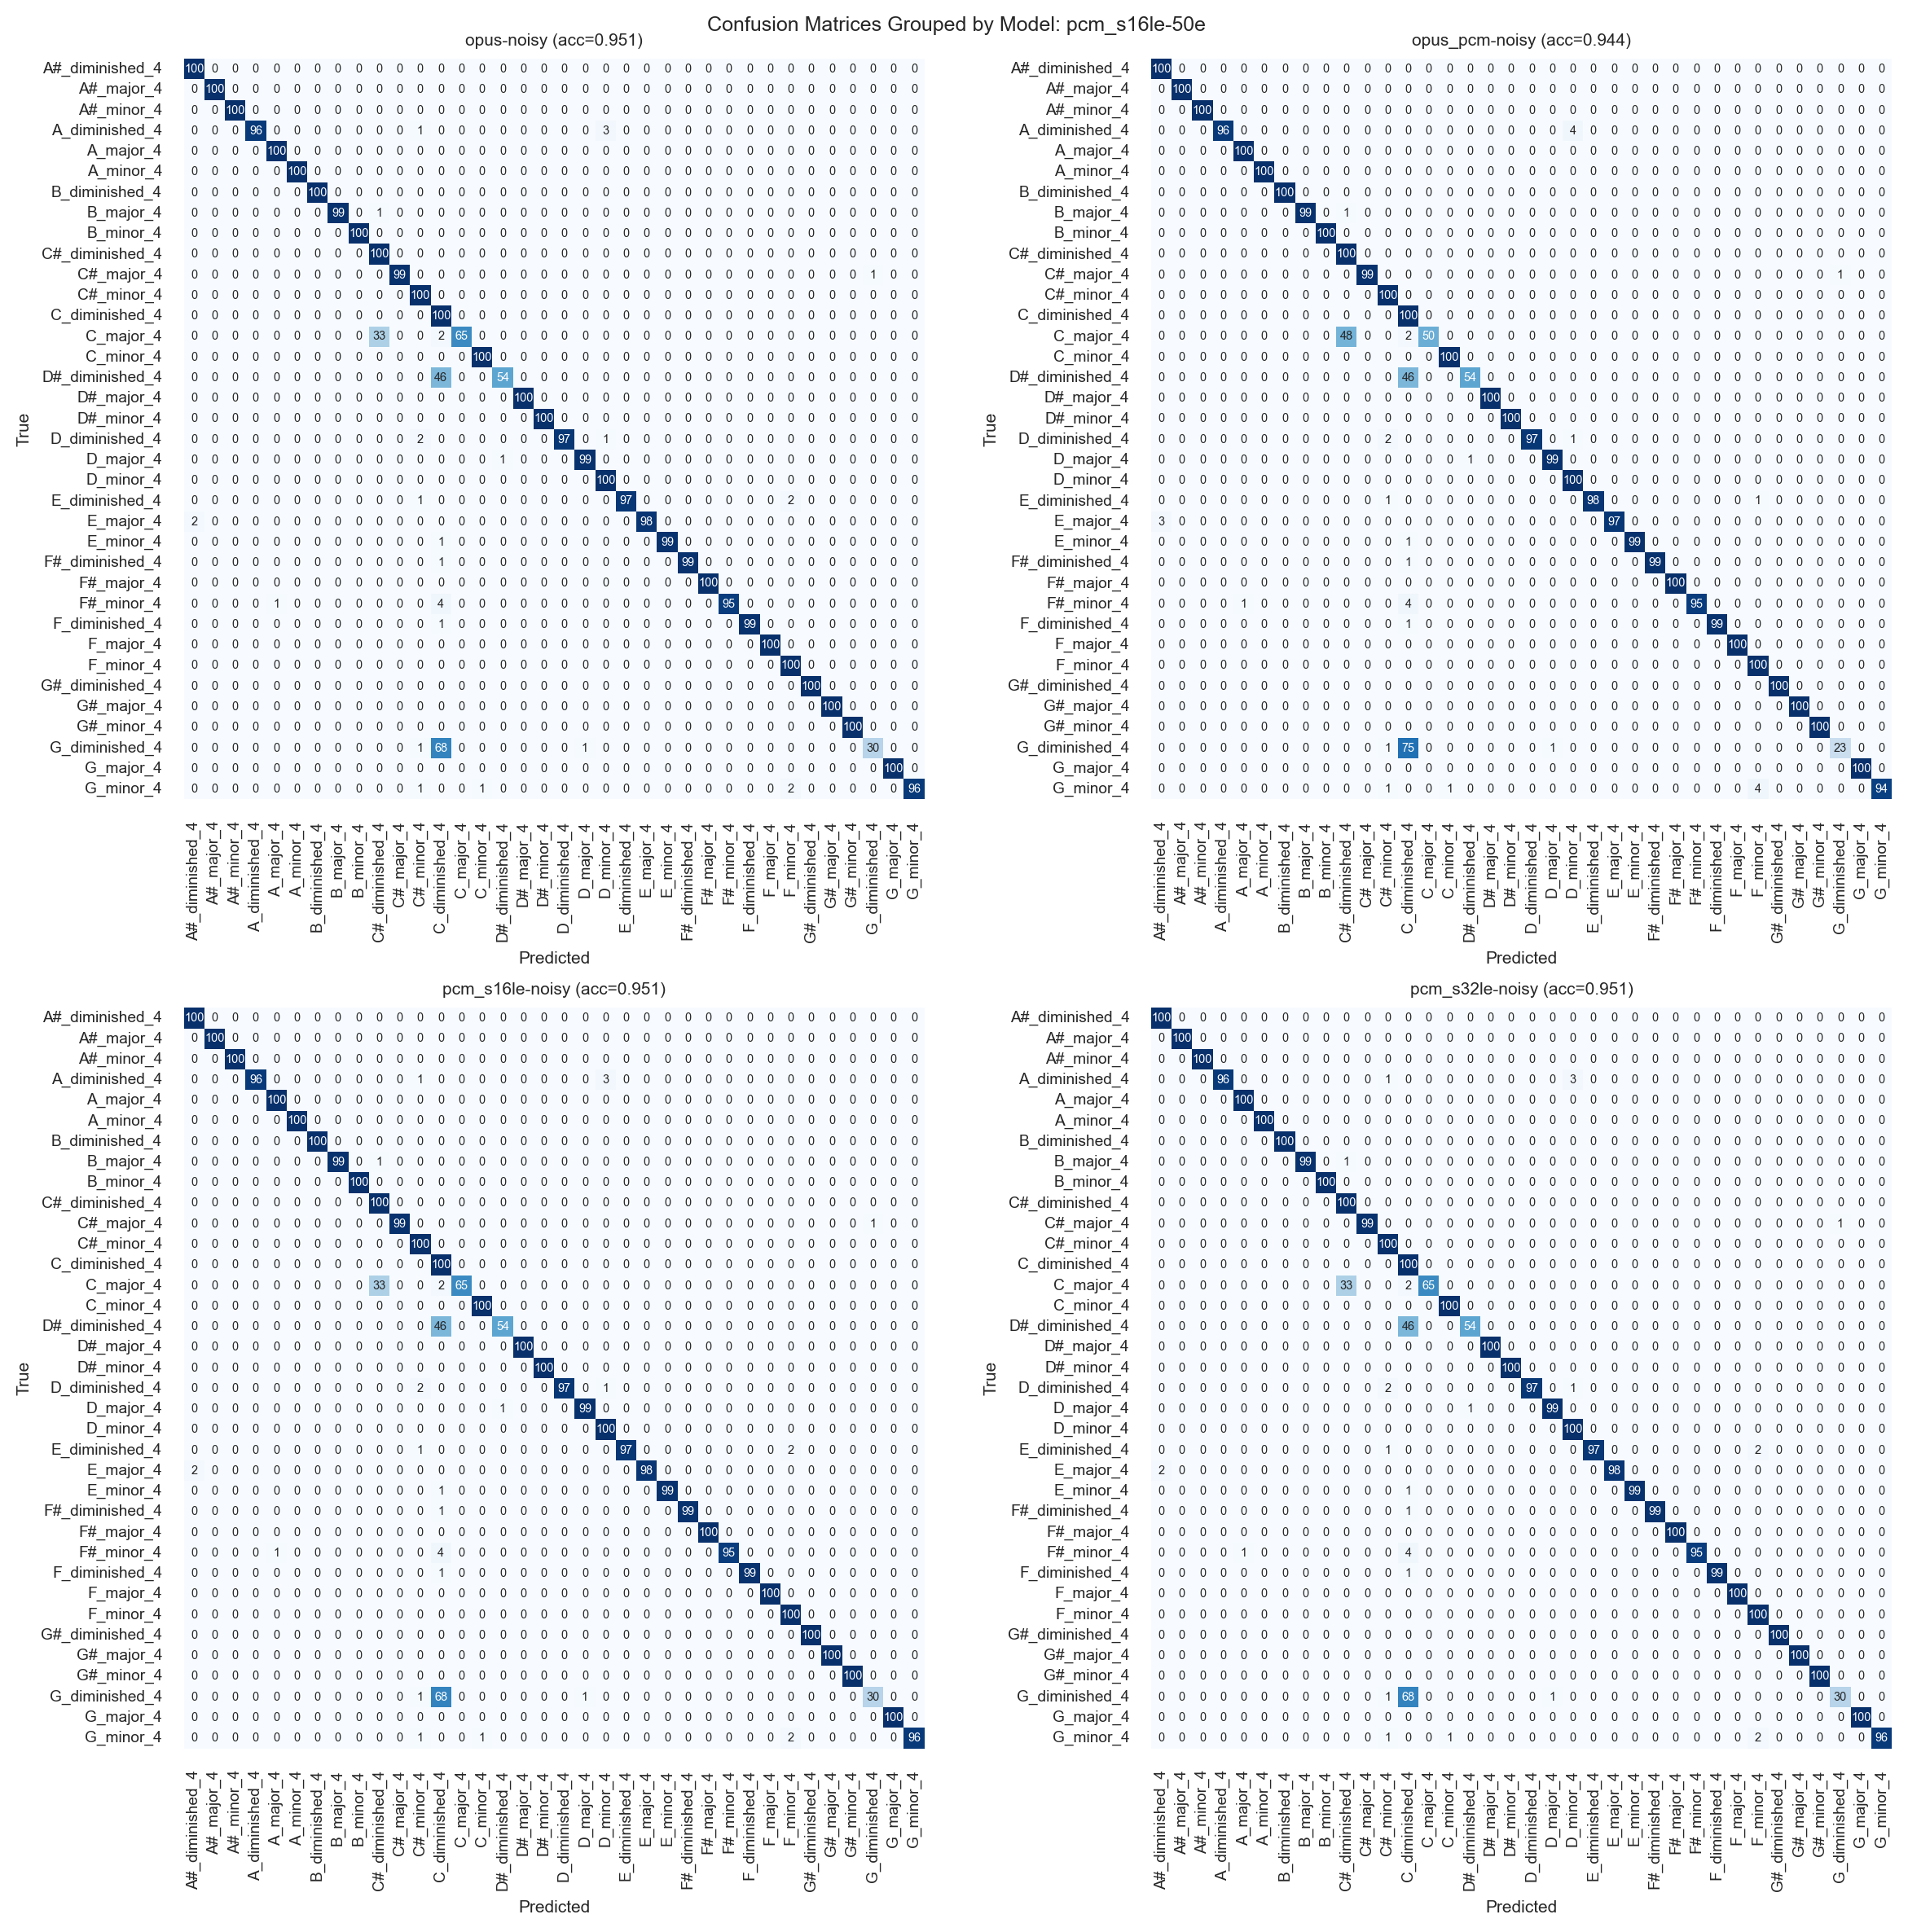

Finished model: pcm_s16le-50e

[5/5] Evaluating model: pcm_s32le-50e


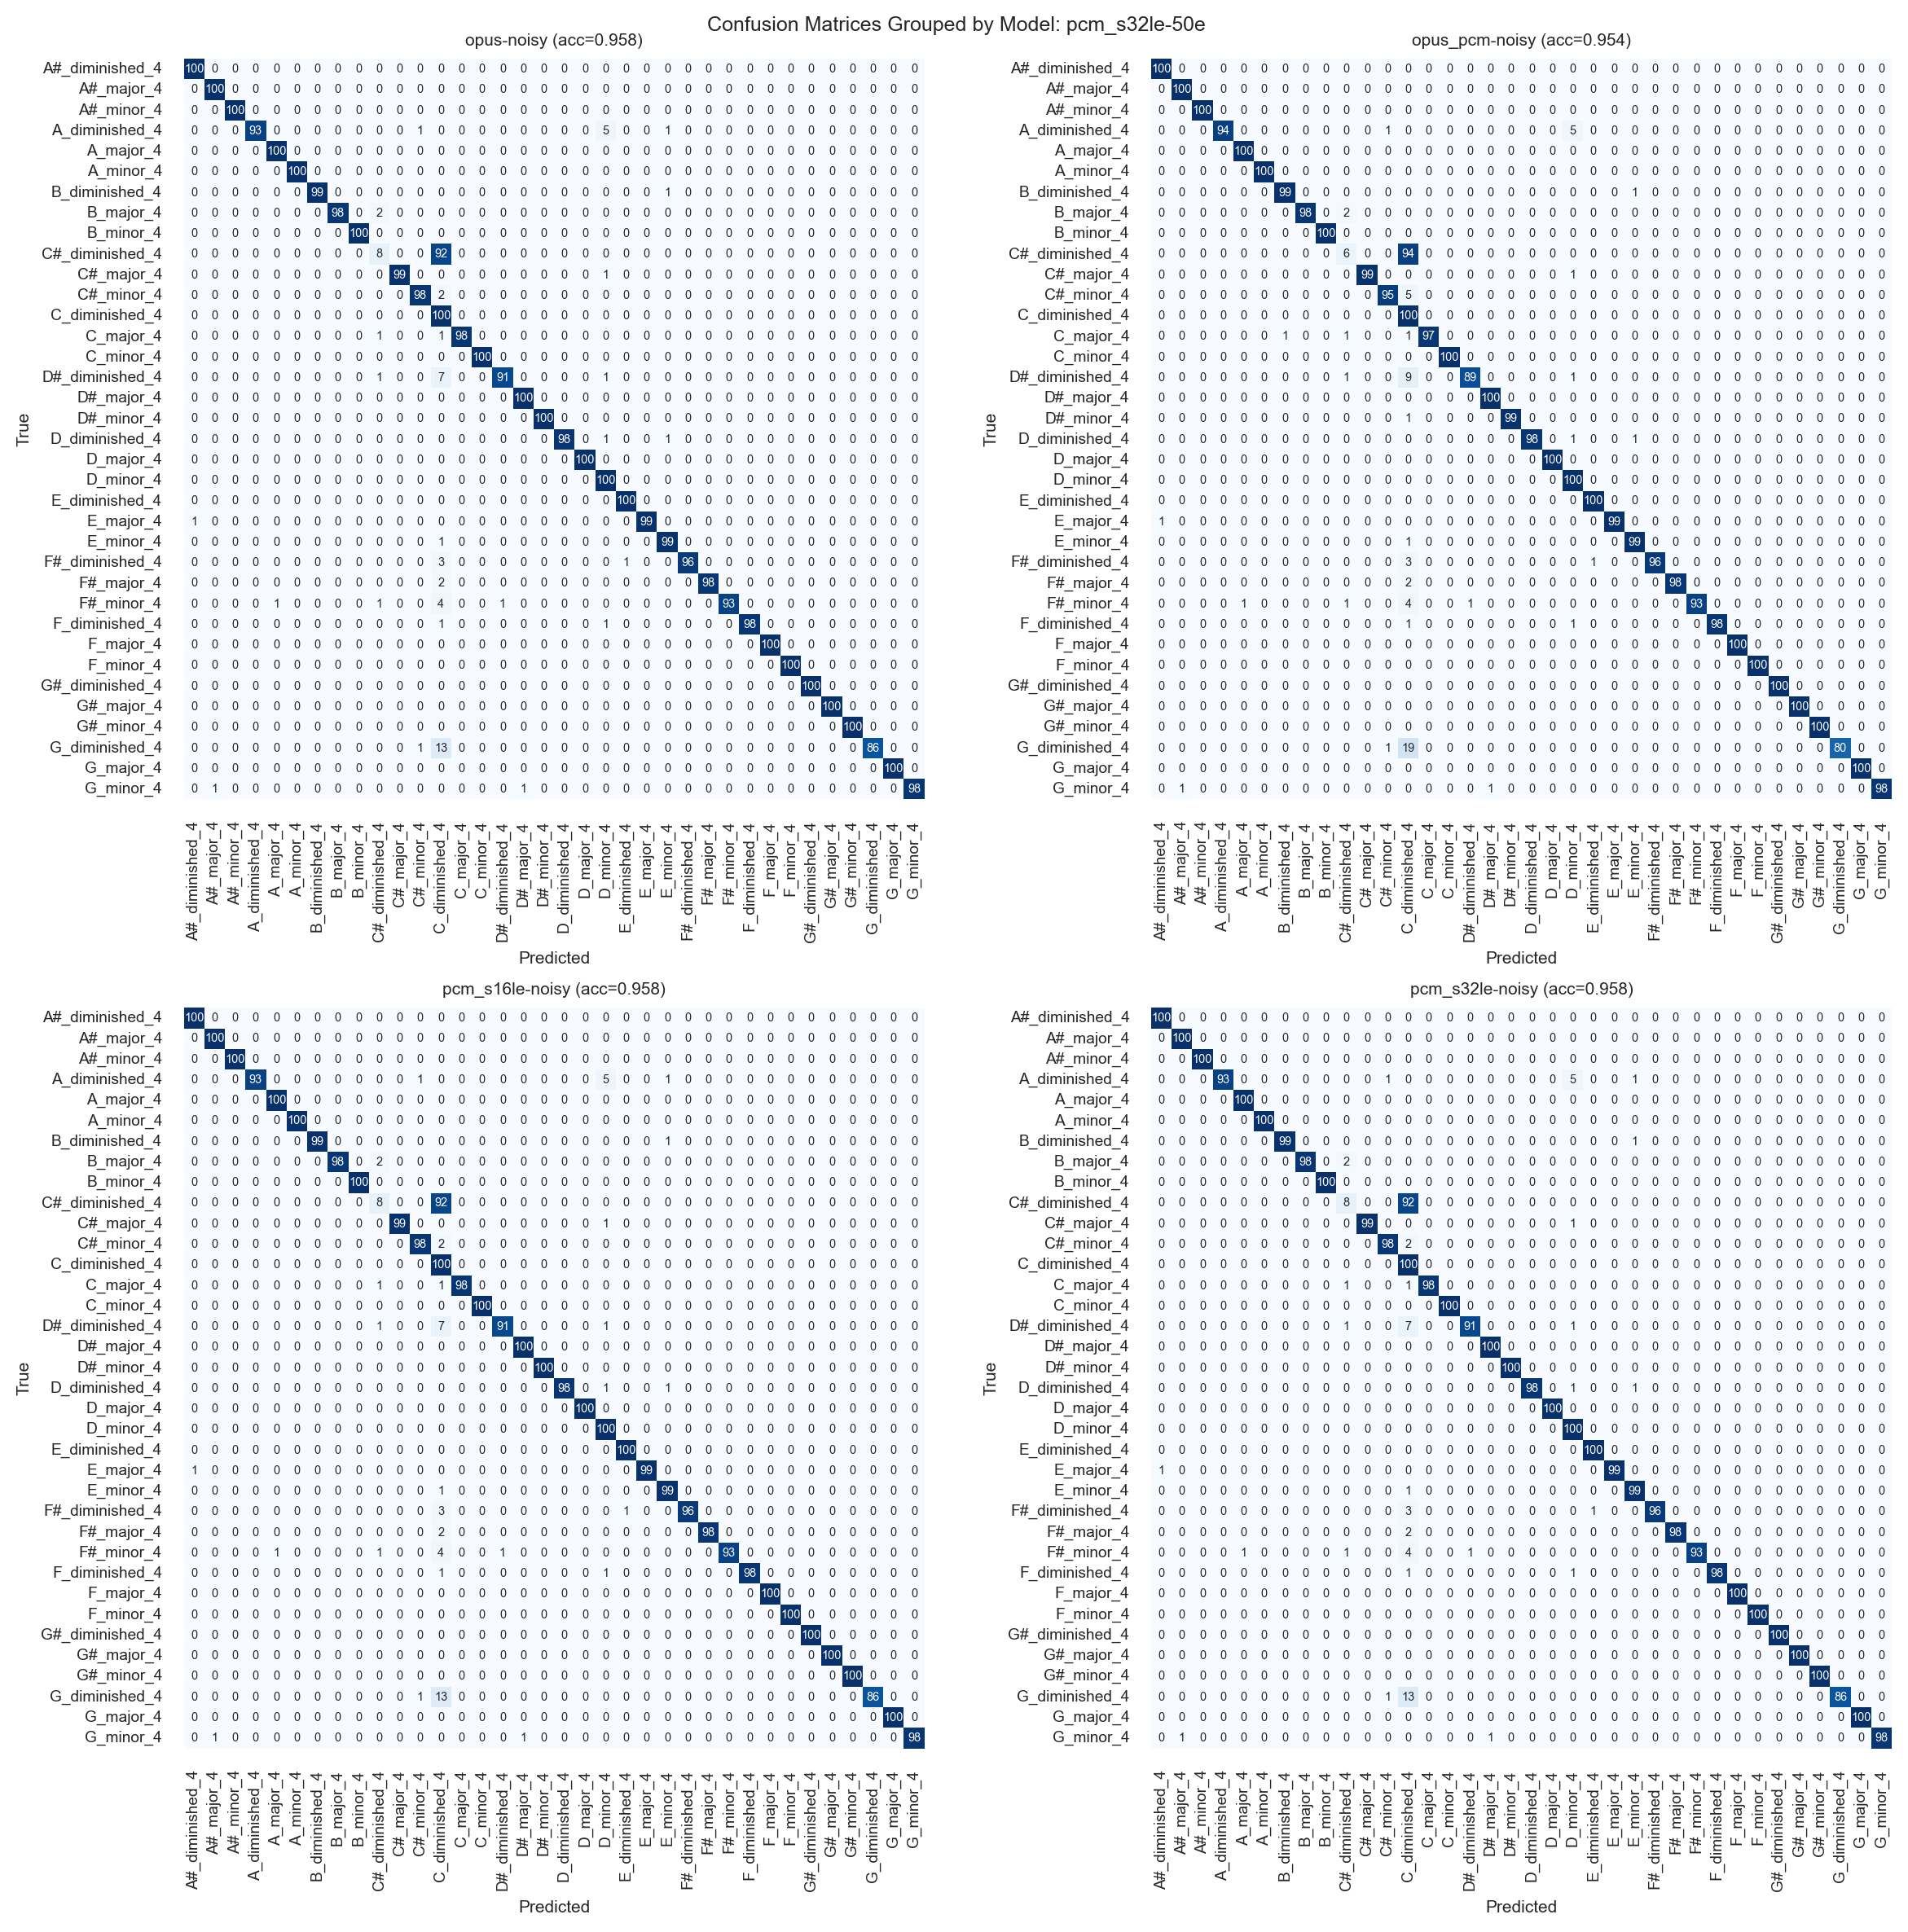

Finished model: pcm_s32le-50e

Done. Generated up to 20 confusion matrices.


In [6]:
%config InlineBackend.figure_format = 'retina'

def ensure_channel_dimension(features: np.ndarray) -> np.ndarray:
    if features.ndim == 3:
        return np.expand_dims(features, axis=-1)
    if features.ndim == 4:
        return features
    raise ValueError(f"Unexpected feature shape: {features.shape}")


def predict_safely(model: tf.keras.Model, features: np.ndarray) -> np.ndarray:
    # Use CPU inference to avoid GPU/cuDNN OOM during large batch evaluation loops.
    # with tf.device("/CPU:0"):
    return model.predict(features, batch_size=32, verbose=0)

results = {}
sns.set_theme(font_scale=0.625)

for model_index, model_path in enumerate(model_files, start=1):
    model_name = model_path.stem
    print(f"\n[{model_index}/{len(model_files)}] Evaluating model: {model_name}")

    model = tf.keras.models.load_model(model_path)
    results[model_name] = {}

    n_features = len(feature_files)
    n_cols = min(2, n_features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 6 * n_rows),
        squeeze=False,
    )

    for feature_index, feature_path in enumerate(feature_files):
        feature_name = feature_path.stem
        ax = axes[feature_index // n_cols][feature_index % n_cols]

        dataset = feature_cache[feature_name]
        x = ensure_channel_dimension(dataset["features"])
        labels = dataset["labels"]

        label_encoder = LabelEncoder()
        y_true = label_encoder.fit_transform(labels)
        class_labels = [str(label) for label in label_encoder.classes_]

        predictions = predict_safely(model, x)
        y_pred = np.argmax(predictions, axis=1)

        if predictions.shape[1] != len(class_labels):
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                "Class count mismatch\nmodel output != labels",
                ha="center",
                va="center",
                fontsize=10,
            )
            results[model_name][feature_name] = {
                "error": "Class count mismatch",
                "model_output_classes": int(predictions.shape[1]),
                "feature_label_classes": int(len(class_labels)),
            }
            continue

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_labels)))
        accuracy = float(np.mean(y_true == y_pred))
        report = classification_report(
            y_true,
            y_pred,
            target_names=class_labels,
            zero_division=0,
        )

        results[model_name][feature_name] = {
            "confusion_matrix": cm,
            "accuracy": accuracy,
            "classification_report": report,
            "classes": class_labels,
        }

        sns.heatmap(
            cm,
            ax=ax,
            annot=True,
            annot_kws={"fontsize": "x-small"},
            cmap="Blues",
            cbar=False,
            fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            square=True,
        )
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"{feature_name} (acc={accuracy:.3f})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    for empty_axis in axes.ravel()[n_features:]:
        empty_axis.axis("off")

    fig.suptitle(f"Confusion Matrices Grouped by Model: {model_name}")
    plt.tight_layout()
    plt.show()

    print(f"Finished model: {model_name}")

    del model
    tf.keras.backend.clear_session()

print(f"\nDone. Generated up to {len(model_files) * len(feature_files)} confusion matrices.")

In [4]:
REPORT_ONLY_INACCURACIES = True
DECIMALS = 4

per_class_reports = []

for model_name, feature_results in results.items():
    for feature_name, result in feature_results.items():
        if (
            "confusion_matrix" not in result
            or "classes" not in result
            or "accuracy" not in result
        ):
            continue

        overall_accuracy = result["accuracy"]
        cm = np.asarray(result["confusion_matrix"], dtype=np.float64)
        class_labels = [str(label) for label in result["classes"]]

        if cm.shape[0] != cm.shape[1] or cm.shape[0] != len(class_labels):
            print(
                f"Skipping {model_name} x {feature_name}: invalid confusion matrix shape {cm.shape}"
            )
            continue

        support = cm.sum(axis=1)
        correct = np.diag(cm)
        class_accuracy = np.divide(
            correct,
            support,
            out=np.full_like(correct, np.nan, dtype=np.float64),
            where=support > 0,
        )

        per_class_reports.append(
            {
                "model": model_name,
                "feature": feature_name,
                "overall_accuracy": overall_accuracy,
                "classes": class_labels,
                "class_accuracy": class_accuracy,
                "correct": correct,
                "support": support,
            }
        )

if not per_class_reports:
    print("No model-feature pairs matched the reporting filter.")
else:
    scope_text = "below 100% accuracy" if REPORT_ONLY_INACCURACIES else "all evaluated pairs"
    print(f"Per-class accuracy report for {scope_text}:")

    for report in per_class_reports:
        print(
            f"\n{report['model']} x {report['feature']} | overall_accuracy={report['overall_accuracy']:.{DECIMALS}%}"
        )
        print("Class accuracies (accuracy = correct/support):")

        for label, acc, corr, supp in zip(
            report["classes"],
            report["class_accuracy"],
            report["correct"],
            report["support"],
        ):
            if REPORT_ONLY_INACCURACIES and corr == supp:
              continue
            acc_text = "N/A" if np.isnan(acc) else f"{acc:.{DECIMALS}%}"
            print(f"  {label:>16} : {acc_text} ({int(corr)}/{int(supp)})")

Per-class accuracy report for below 100% accuracy:

opus-50e x opus-noisy | overall_accuracy=95.0556%
Class accuracies (accuracy = correct/support):
    A_diminished_4 : 96.0000% (96/100)
         B_major_4 : 99.0000% (99/100)
        C#_major_4 : 99.0000% (99/100)
         C_major_4 : 65.0000% (65/100)
   D#_diminished_4 : 54.0000% (54/100)
    D_diminished_4 : 97.0000% (97/100)
         D_major_4 : 99.0000% (99/100)
    E_diminished_4 : 97.0000% (97/100)
         E_major_4 : 98.0000% (98/100)
         E_minor_4 : 99.0000% (99/100)
   F#_diminished_4 : 99.0000% (99/100)
        F#_minor_4 : 95.0000% (95/100)
    F_diminished_4 : 99.0000% (99/100)
    G_diminished_4 : 30.0000% (30/100)
         G_minor_4 : 96.0000% (96/100)

opus-50e x opus_pcm-noisy | overall_accuracy=94.3889%
Class accuracies (accuracy = correct/support):
    A_diminished_4 : 96.0000% (96/100)
         B_major_4 : 99.0000% (99/100)
        C#_major_4 : 99.0000% (99/100)
         C_major_4 : 50.0000% (50/100)
   D#_di